## Markov chain:

You are a real astronomer (not a theory guy like me) and are planning an expensive observational campaign. You want to know how likely it is that tomorrow night will be clear given the weather tonight (clear or cloudy). The key piece of information here is that the weather tomorrow depends on the weather today. From past history, you know that:

$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

which means that

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$

We also have

$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

which means that

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$


- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at

$$p({\rm clear}) = 0.83,$$

and 

$$p({\rm cloudy}) = 0.17.$$

You get the same answer for day $N$ as day $N+1$ and it doesn't matter whether it was clear or cloudy on the day that you started. The steps that we have taken in this process are, indeed, a **MARKOV CHAIN**.

#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.  
- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.
- Use a summary statistics to determine the most likely value and an error on our estimate.

**Important:** 
- In MCMC the process must be **stationary** which basically means that the chain statistics look the same no matter which chunk you look at, e.g. first half, second half, or every other point, etc.  
- Obviously that isn't going to be the case in the early steps of the chain. In our example above, after some time the process was stationary, but not in the first few days.
- So, there is a **burn-in** phase that needs to be discarded. How one determines the number of early steps to discard as burn-in is tricky, but ***you should always start with a traceplot of your samples!***

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from astroML import stats as statsML

In [16]:
# 0 = clear sky
# 1 = cloudy sky 
sky = np.array([0, 1]) #Possible sky conditions
cloud_rn = np.array([0.5, 0.5]) #Prob of clear/cloudy sky if today is cloudy 
clear_rn = np.array([0.9, 0.1]) #Prob of clear/cloudy sky if today is clear 
N = 1e5 #n. of days we want to forecast 
sunny_days = 0
rel_sun = [] #keep track of the relative number of sunny days 

#Starting from a cloudy day!
sky_rn = 1
prev = [] #Let's store here the data
prev.append(sky_rn)
rel_sun.append(0)
while len(prev) < N:
    if sky_rn == 1:
        sky_rn = np.random.choice(sky, p = cloud_rn)
        prev.append(sky_rn)
        if sky_rn == 0:
            sunny_days +=1
        rel_sun.append(sunny_days/len(prev))
    else:
        sky_rn = np.random.choice(sky, p = clear_rn)
        prev.append(sky_rn)
        if sky_rn == 0:
            sunny_days +=1
        rel_sun.append(sunny_days/len(prev))

prev = np.array(prev)
rel_sun = np.array(rel_sun)
days = np.arange(0, N)

Text(0.5, 1.0, 'Trace Plot')

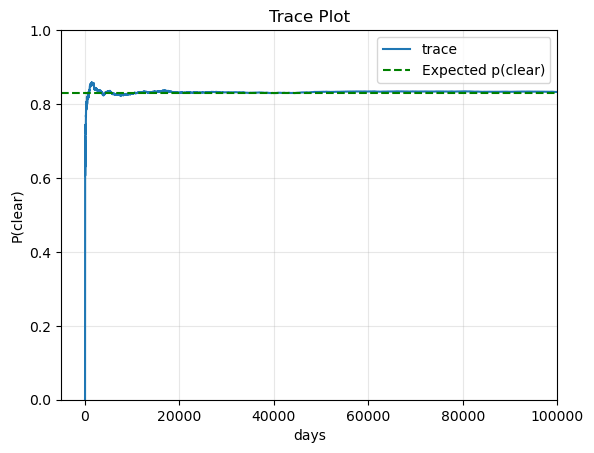

In [17]:
plt.plot(days, rel_sun, label = 'trace')
plt.hlines(0.83, -5000, 110000,color = 'green', linestyle = '--', label = 'Expected p(clear)')
plt.xlabel('days')
plt.ylabel('P(clear)')
plt.grid(alpha = 0.3)
plt.ylim(0, 1.0)
plt.xlim(-5000, 100000)
plt.legend()
plt.title('Trace Plot')

The $p(clear)$ seems to stabilize around the value of 0.83 as expected, bu we can clearly see that we have some burn-in effect! Let's try to see where we should cut our data to remove such effect.

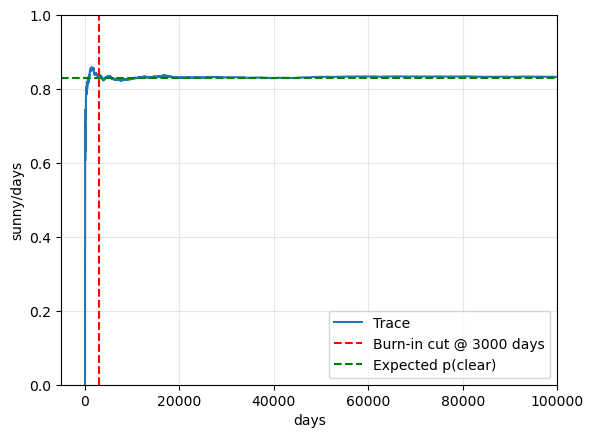

In [18]:
plt.plot(days, rel_sun, label = 'Trace')
plt.vlines(3000, 0, 1.1, color = 'r', linestyle = '--', label = 'Burn-in cut @ 3000 days')
plt.hlines(0.83, -5000, 110000,color = 'green', linestyle = '--', label = 'Expected p(clear)')
plt.xlabel('days')
plt.ylabel('sunny/days')
plt.grid(alpha = 0.3)
plt.ylim(0, 1.0)
plt.xlim(-5000, 100000)
plt.legend()

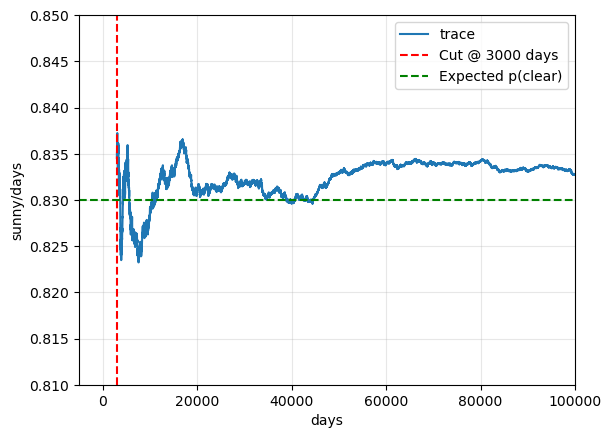

In [19]:
#More 'conservative' approach
cons_cut = 3000
plt.plot(days[cons_cut-1:], rel_sun[cons_cut-1:], label = 'trace')
plt.vlines(cons_cut, 0.81, 0.85, color = 'r', linestyle = '--', label = 'Cut @ 3000 days')
plt.ylim(0.81, 0.85)
plt.hlines(0.83, -5000, 110000,color = 'green', linestyle = '--', label = 'Expected p(clear)')
plt.grid(alpha = 0.3)
plt.xlabel('days')
plt.ylabel('sunny/days')
plt.xlim(-5000, 100000)
plt.legend()

Maybe we should cut a bit more to remove the few big oscillations we have the beginning  of our Markov chain.

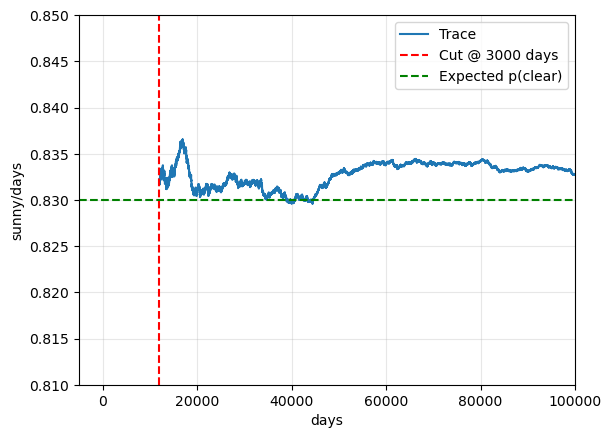

In [20]:
cut  = 12000
plt.plot(days[cut-1:], rel_sun[cut-1:], label = 'Trace')
plt.vlines(cut, 0.81, 0.85, color = 'r', linestyle = '--', label = 'Cut @ 3000 days')
plt.ylim(0.81, 0.85)
plt.hlines(0.83, -5000, 110000,color = 'green', linestyle = '--', label = 'Expected p(clear)')
plt.xlabel('days')
plt.ylabel('sunny/days')
plt.grid(alpha = 0.3)
plt.xlim(-5000, 100000)
plt.legend()

Ok, it looks better, but did we cut too much ? 

Let's now do an hist of our data to find a pdf and some statistics.

The mean is : 0.8328
The sigma G is : 0.0016


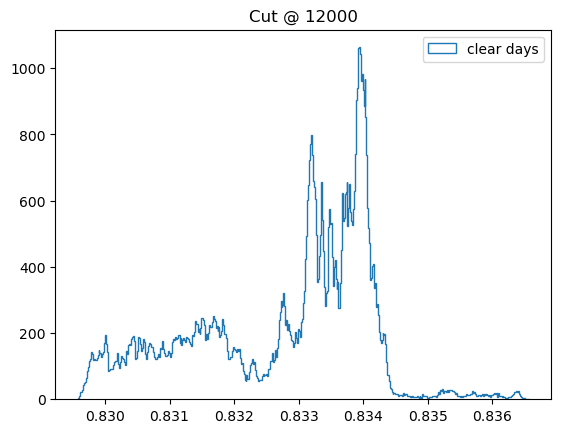

In [21]:
_ = plt.hist(rel_sun[cut-1:], bins = 500, histtype = 'step', label = 'clear days')
plt.legend()
plt.title(f'Cut @ {cut}')
print(f'The mean is : {np.mean(rel_sun[cut-1:]):.4f}')
print(f'The sigma G is : {statsML.sigmaG(rel_sun[cut-1:]):.4f}')

What if we didn't cut the burn in ? Let's check !

The mean is : 0.8322
The sigma G is : 0.0019


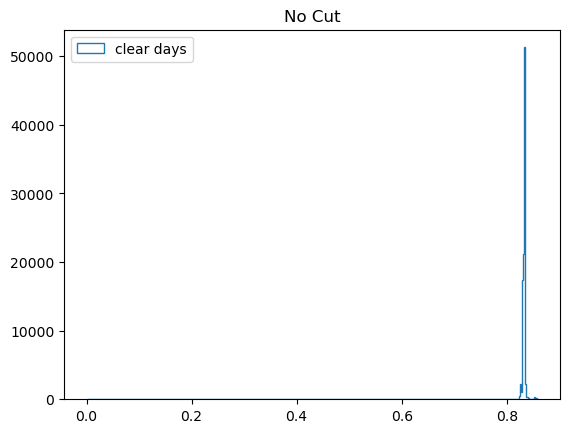

In [22]:
_ = plt.hist(rel_sun, bins = 500, histtype = 'step', label = 'clear days')
plt.legend()
plt.title('No Cut')
print(f'The mean is : {np.mean(rel_sun):.4f}')
print(f'The sigma G is : {statsML.sigmaG(rel_sun):.4f}')

While the statistics we computed are practically the same, the histogram is much worse! We can't see anyting!

Let's check what we would have gotten with our more 'conservative' approach.

The mean is : 0.8324
The sigma G is : 0.0018


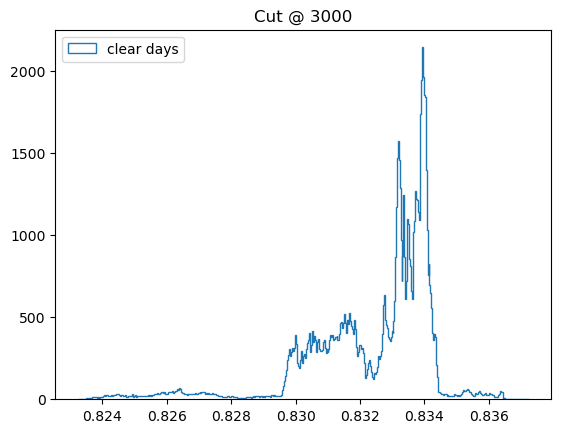

In [23]:
_ = plt.hist(rel_sun[cons_cut-1:], bins = 500, histtype = 'step', label = 'clear days')
plt.legend()
plt.title(f'Cut @ {cons_cut}')
print(f'The mean is : {np.mean(rel_sun[cons_cut-1:]):.4f}')
print(f'The sigma G is : {statsML.sigmaG(rel_sun[cons_cut-1:]):.4f}')

Better than having no cut at all, but we still have very long tails!

#### More

- Redo the same for the Markovian process describing the stock market. If you've written your code well, this should require minor modifications.

In [28]:
# 0 = Stagnant market
# 1 = Bull market 
# 2 = Bear market
mrkt = np.array([0, 1, 2]) #Possible market conditions
bull_rn = np.array([0.025, 0.90, 0.075]) #Prob of other conditions if today is bull 
bear_rn = np.array([0.050, 0.15, 0.800]) #Prob of other conditions if today is bear  
stgn_rn = np.array([0.500, 0.25, 0.250]) #Prob of other conditions if today is stagnant 
N = 1e5 #n. of days we want to forecast 
recession_days = 0
rel_rec = [] #keep track of the relative number of sunny days 

#Starting from a bear market!
mrkt_rn = 2
prev = [] #Let's store here the data
prev.append(mrkt_rn)
rel_rec.append(0)
while len(prev) < N:
    if mrkt_rn == 2: #Bear case
        mrkt_rn = np.random.choice(mrkt, p = bear_rn)
        prev.append(mrkt_rn)
        if mrkt_rn == 0:
            recession_days +=1
        rel_rec.append(recession_days/len(prev))
        
    elif mrkt_rn == 1: #Bull case
        mrkt_rn = np.random.choice(mrkt, p = bull_rn)
        prev.append(mrkt_rn)
        if mrkt_rn == 0:
            recession_days +=1
        rel_rec.append(recession_days/len(prev))
        
    else: #Stagnant case
        mrkt_rn = np.random.choice(mrkt, p = stgn_rn)
        prev.append(mrkt_rn)
        if mrkt_rn == 0:
            recession_days +=1
        rel_rec.append(recession_days/len(prev))

prev = np.array(prev)
rel_rec = np.array(rel_rec)
days = np.arange(0, N)

Text(0.5, 1.0, 'Trace Plot')

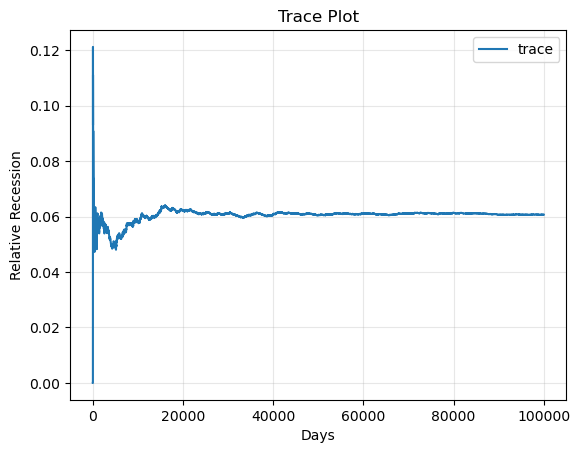

In [29]:
plt.plot(days, rel_rec, label = 'trace')
plt.grid(alpha = 0.3)
plt.legend()
plt.ylabel('Relative Recession')
plt.xlabel('Days')
plt.title('Trace Plot')

Again we have some burn in effect to remove! Let's do it.

Text(0.5, 0, 'Days')

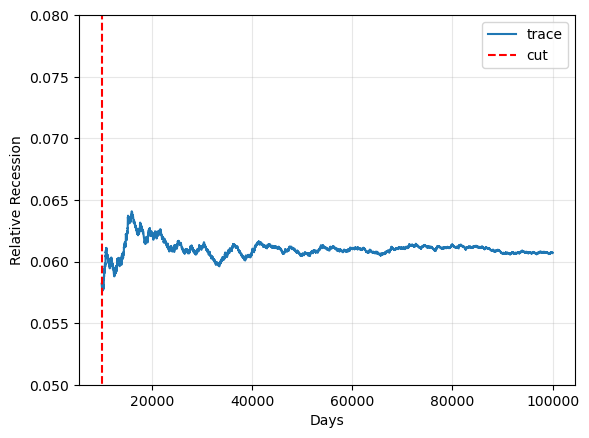

In [30]:
cut = 10000
plt.plot(days[cut:], rel_rec[cut:], label = 'trace')
plt.vlines(cut, 0, 1, color = 'r', linestyle = '--', label = 'cut')
plt.ylim(0.05, 0.08)
plt.legend()
plt.grid(alpha=0.3)
plt.ylabel('Relative Recession')
plt.xlabel('Days')

Much better! Let's do a histogram.

The mean of p(recession) is 0.0604
The sigma G is 0.0004


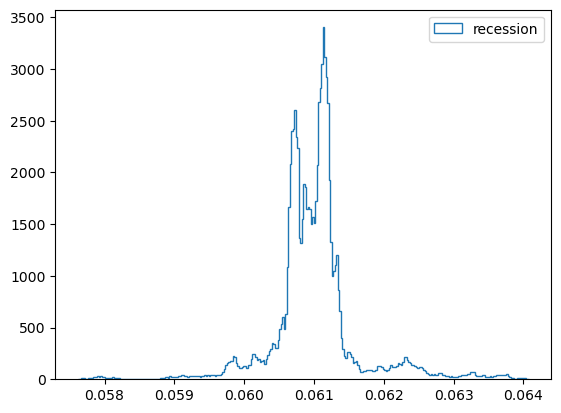

In [31]:
_ = plt.hist(rel_rec[cut:], bins = 300, label = 'recession', histtype = 'step')
plt.legend()
print(f'The mean of p(recession) is {np.mean(rel_rec):.4f}')
print(f'The sigma G is {statsML.sigmaG(rel_rec):.4f}')